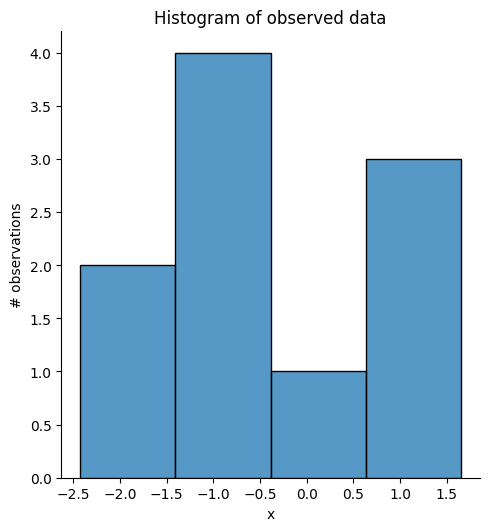

In [31]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate synthetic data: 10 samples from a Normal(0, 1)
np.random.seed(123)
data = np.random.randn(10)

fig = sns.displot(data, kde=False, binwidth=1)
fig.set(title='Histogram of observed data', xlabel='x', ylabel='# observations')


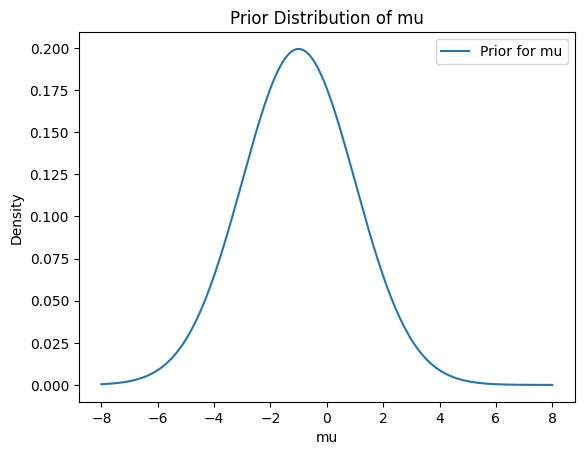

In [24]:
# Define your prior parameters
mu_prior = -1
sigma_prior = 2.0

# Plot the prior distribution for mu
mus = np.linspace(-8, 8, 200)
prior_vals = norm(mu_prior, sigma_prior).pdf(mus)

plt.plot(mus, prior_vals, label='Prior for mu')
plt.title("Prior Distribution of mu")
plt.xlabel("mu")
plt.ylabel("Density")
plt.legend()
plt.show()

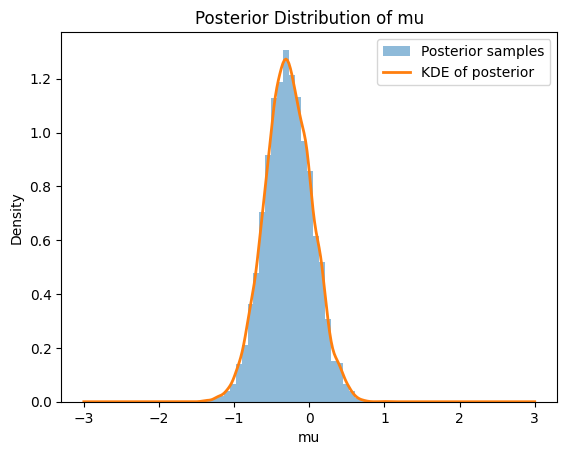

In [ ]:
import scipy.stats as st


# Define the unnormalized posterior: likelihood * prior
def posterior(mu, data, mu_prior=-1, sigma_prior=2, sigma=1):
    # Likelihood: product of probabilities of each data point
    likelihood = np.prod(norm(mu, sigma).pdf(data))
    # Prior: assume a Normal(mu_prior, sigma_prior)
    prior = norm(mu_prior, sigma_prior).pdf(mu)
    return likelihood * prior

# Implement the Metropolis sampler
def metropolis_sampler(data, num_samples=10000, mu_init=1.0, proposal_width=0.5):
    samples = [mu_init]
    current_mu = mu_init
    for _ in range(num_samples):
        # Propose a new mu by drawing from a normal distribution centered at the current value
        proposal = norm(current_mu, proposal_width).rvs()
        # Compute the acceptance ratio
        p_current = posterior(current_mu, data)
        p_proposal = posterior(proposal, data)
        acceptance_ratio = p_proposal / p_current
        # Accept or reject the proposal based on the acceptance ratio
        if np.random.rand() < acceptance_ratio:
            current_mu = proposal
        samples.append(current_mu)
    return np.array(samples)

# Run the sampler
samples = metropolis_sampler(data, num_samples=10000, mu_init=1.0, proposal_width=0.5)

# Posterior samples are in "samples"
plt.hist(samples, bins=30, density=True, alpha=0.5, label='Posterior samples')

# Overlaid approximate KDE for the posterior
kde = st.gaussian_kde(samples)
mus_dense = np.linspace(-3, 3, 300)
plt.plot(mus_dense, kde(mus_dense), label='KDE of posterior', linewidth=2)

plt.xlabel('mu')
plt.ylabel('Density')
plt.title('Posterior Distribution of mu')
plt.legend()
plt.show()

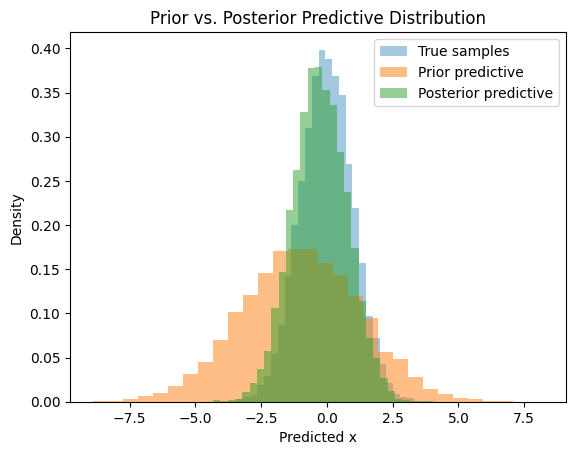

In [33]:
sigma = 1.0

num_draws = 10000


true_samples = norm(0, 1).rvs(num_draws)

mus_from_prior = norm(mu_prior, sigma_prior).rvs(num_draws)
prior_predictive_samples = norm.rvs(loc=mus_from_prior, scale=sigma)

# 2) Posterior predictive (you already have this):
posterior_predictive_samples = norm.rvs(loc=samples, scale=sigma)

plt.hist(true_samples, bins=30, density=True, alpha=0.4, label='True samples')
plt.hist(prior_predictive_samples, bins=30, density=True, alpha=0.5, label='Prior predictive')
plt.hist(posterior_predictive_samples, bins=30, density=True, alpha=0.5, label='Posterior predictive')
plt.xlabel('Predicted x')
plt.ylabel('Density')
plt.title('Prior vs. Posterior Predictive Distribution')
plt.legend()
plt.show()